#**Regression Course**


---


In this course, you will learn how to apply ***the supervised learning workflow (explained in Section 4 of the lecture) to regression problems***. We will use **"linear regression" model** throughout the exercises and look at each step of the workflow: ***understanding the data, processing data, model building, and model evaluation***.The goal is to practice the knowledge required for each step depending on the level.

#Level 1 (★☆☆☆)



---


Level 1 builds on the methods introduced in Level 0 and applies them to more practical datasets, with a focus on processing data and model building.

##1.1. Understanding the Data

Let’s begin by exploring the dataset we'll be working with. This step is essential for effective data transformation and model building later on. The dataset contains approximately 200 rows related to appearances and performance of different cars. Unlike Level 0, understanding this data won’t be as straightforward. Start by examining a few dozen rows directly, then analyze each feature in more detail.

First, download the `Car_Price_Data.csv` from the link below. Hover over the blue text, click to open the page, and click the download button. If you don't see the button, click the ︙ (More Options) icon and select "Download" from the menu.

[Car_Price_Data.csv](https://drive.google.com/file/d/1YVQgy_jAwSVH5YEMdWlrTzkXEf7no860/view?usp=drive_link)

After downloading, drag and drop the CSV file into the same location you used in Level 0. (Click and hold the left mouse button on the file, then move it to the desired location). Once uploaded, use the following code to read the CSV file and display it as a DataFrame.

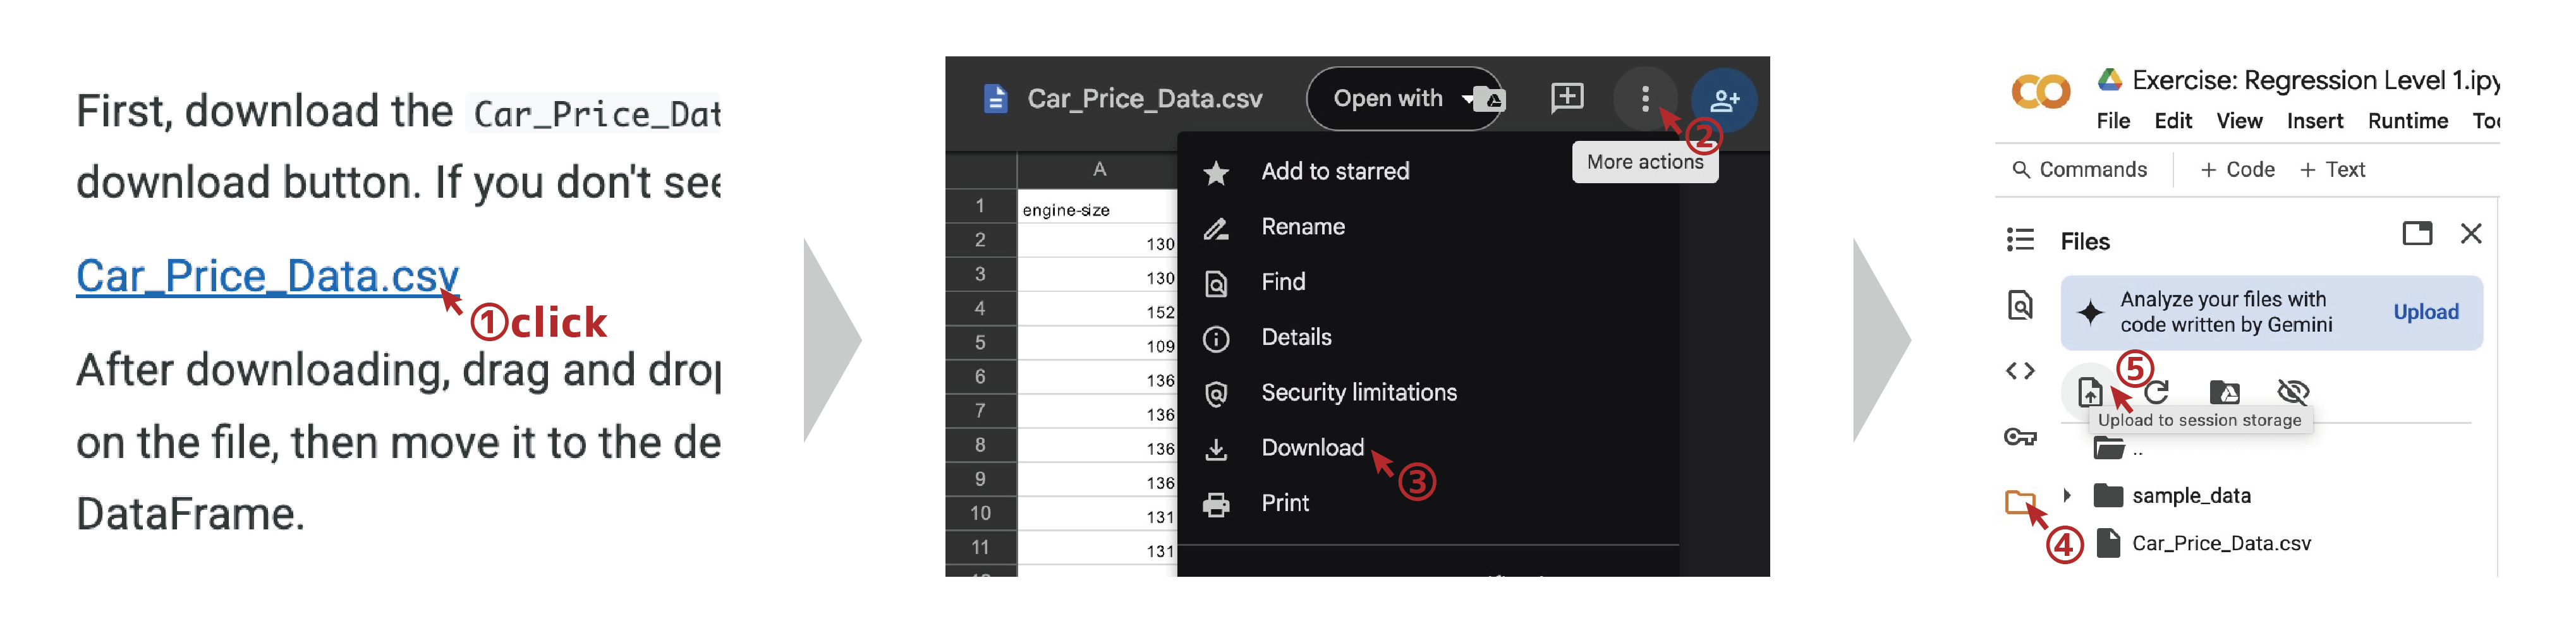

In [ ]:
import pandas as pd

df = pd.read_csv('Car_Price_Data.csv')

df

,engine-size,city-mpg,curb-weight,price
0,130,21,2548,13495.0
1,130,21,2548,16500.0
2,152,19,2823,16500.0
3,109,24,2337,13950.0
4,136,18,2824,17450.0
...,...,...,...,...
200,141,23,2952,16845.0
201,141,19,3049,19045.0
202,173,18,3012,21485.0
203,145,26,3217,22470.0


You can use the `len()` function to check how many rows the DataFrame contains.

In [ ]:
len(df)

205

Since the dataset contains around 200 rows, only the first and last five rows are displayed by default, and the rest are hidden from view. To display a specific number of rows from the beginning, you can use the DataFrame’s `head()` method with the desired number as an argument.

In [ ]:
df.head(10)

,engine-size,city-mpg,curb-weight,price
0,130,21,2548,13495.0
1,130,21,2548,16500.0
2,152,19,2823,16500.0
3,109,24,2337,13950.0
4,136,18,2824,17450.0
5,136,19,2507,15250.0
6,136,19,2844,17710.0
7,136,19,2954,18920.0
8,131,17,3086,23875.0
9,131,16,3053,NaN


If you want to check records from the bottom instead, you can use the `tail()` method.

In [ ]:
df.tail(10)

,engine-size,city-mpg,curb-weight,price
195,141,23,3034,13415.0
196,141,24,2935,15985.0
197,141,24,3042,16515.0
198,130,17,3045,18420.0
199,130,17,3157,18950.0
200,141,23,2952,16845.0
201,141,19,3049,19045.0
202,173,18,3012,21485.0
203,145,26,3217,22470.0
204,141,19,3062,22625.0


The dataset includes four quantitative features: `engine-size`, `curb-weight` (vehicle weight), and `city-mpg` (fuel efficiency in city conditions) and `price`. We will build a model to predict car prices from the first three features. Note that the `price` column contains `NaN` entries. `NaN` stands for **Not a Number**, indicating missing values. In the CSV file, these appear as blank cells.


Checking for missing values is essential in real-world data analysis. A **missing value** refers to a data point that, for some reason, was not recorded and therefore does not exist. Since analysis cannot proceed properly when missing values are present, the first step when working with a new dataset is to check for them. If missing values are found, we need to handle them appropriately. Although we’ve already seen that the `price` column has missing values, we don’t yet know whether other columns also have them or how many there are in total.

To investigate this, you can use the `isnull()` method of the DataFrame, which returns another DataFrame where each row is either True (if the value is missing) or False (if the value is present).

In [ ]:
df_isnull = df.isnull()
df_isnull

,engine-size,city-mpg,curb-weight,price
0,False,False,False,False
1,False,False,False,False
2,False,False,False,False
3,False,False,False,False
4,False,False,False,False
...,...,...,...,...
200,False,False,False,False
201,False,False,False,False
202,False,False,False,False
203,False,False,False,False


By applying the `sum()` method, True is treated as 1 and False as 0. This counts the number of missing values in each column, making it easy to identify columns with missing rows.

In [ ]:
df_isnull.sum()

,0
engine-size,0
city-mpg,0
curb-weight,0
price,4


Missing values are found only in the `price` column, with a total of 4 rows.

For step-by-step explanation, we first stored the result of the DataFrame’s `isnull()` method in a variable before applying the `sum()` method. However, these methods can also be chained together. From now on, we’ll use the following code to check for missing values:

In [ ]:
df.isnull().sum()

,0
engine-size,0
city-mpg,0
curb-weight,0
price,4


Next, let’s examine the statistical summary of each column. The `describe()` method provides key statistics including the mean, standard deviation, minimum, maximum, and quartiles.

Here, "25%" refers to the data point at the 25th percentile when the data is sorted in ascending order—this is the first quartile (Q1). Similarly, "50%" represents the median, and "75%" indicates the third quartile (Q3).



In [ ]:
df.describe()

,engine-size,city-mpg,curb-weight,price
count,205.000000,205.000000,205.000000,201.000000
mean,126.907317,25.219512,2555.565854,13207.129353
std,41.642693,6.542142,520.680204,7947.066342
min,61.000000,13.000000,1488.000000,5118.000000
25%,97.000000,19.000000,2145.000000,7775.000000
50%,120.000000,24.000000,2414.000000,10295.000000
75%,141.000000,30.000000,2935.000000,16500.000000
max,326.000000,49.000000,4066.000000,45400.000000


Finally, to visualize the relationship between the explanatory variables—`engine-size`, `curb-weight`, and `city-mpg`—and the target variable `price`, we’ll use **scatter plots**. For visualization, we’ll import the `pyplot` module from the Matplotlib library.

In [ ]:
import matplotlib.pyplot as plt

You can create a scatter plot using the `scatter()` function. The first argument specifies the data for the x-axis, and the second specifies the data for the y-axis. In the example below, we use the `engine-size` column for the x-axis and the `price` column for the y-axis. Additionally, the `xlabel()` and `ylabel()` functions set the labels for the x-axis and y-axis, respectively. Finally, the `show()` function displays the plot.


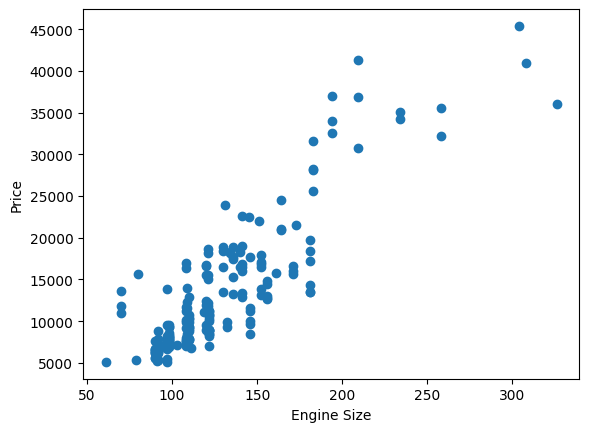

In [ ]:
plt.scatter(df['engine-size'], df['price'])
plt.xlabel('Engine Size')
plt.ylabel('Price')
plt.show()

As we can see, the `price` tends to increase as `engine-size` increases.
Similarly, let's create a scatter plot of `city-mpg` versus `price` to explore their relationship.


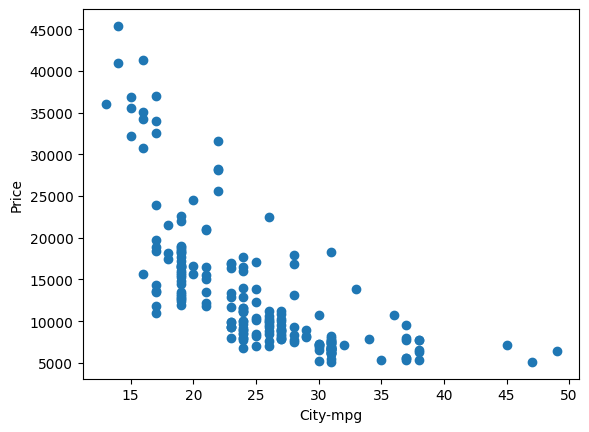

In [ ]:
plt.scatter(df['city-mpg'], df['price'])
plt.xlabel('City-mpg')
plt.ylabel('Price')
plt.show()

Above, the `price` tends to decrease as `city-mpg` increases, indicating an inverse relationship between the two variables.

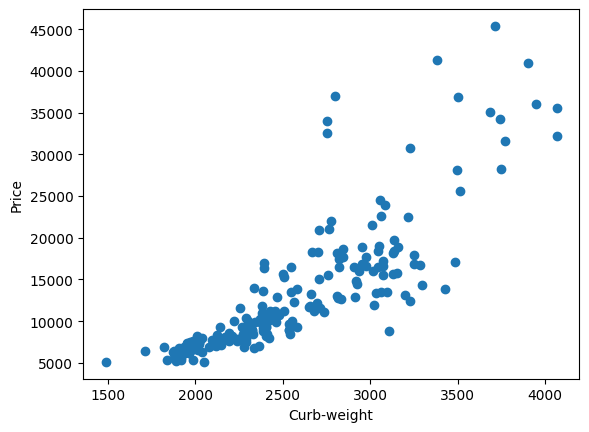

In [ ]:
plt.scatter(df['curb-weight'], df['price'])
plt.xlabel('Curb-weight')
plt.ylabel('Price')
plt.show()

As we can observe, the `price` tends to increase as `curb-weight` increases, indicating a positive relationship between the two variables.

##1.2. Processing Data

Next, we will proceed with processing data.

As we observed in 1.1, some of them contains missing values. To handle these missing values, we use the `dropna()` method to remove any row that contains at least one missing value from the DataFrame.





In [ ]:
df_drop = df.dropna()

Note that the `dropna()` method does not modify the original DataFrame unless you assign the result back or use the `inplace=True` parameter. You can use the `isnull()` method to check for missing values in the original DataFrame.

In [ ]:
df.isnull().sum()

,0
engine-size,0
city-mpg,0
curb-weight,0
price,4


In [ ]:
print('Number of data before removal', len(df))
print('Number of data after removal', len(df_drop))

Number of data before removal 205
Number of data after removal 201


To split the data into explanatory and target variable, you can also remove the target variable (`price`) using the `drop()` method.

The `drop()` method removes specific rows or columns from a DataFrame. The first argument specifies what to remove. By default, `axis=0` (rows), but to remove a column, you must specify `axis=1`.


In [ ]:
X = df_drop.drop('price', axis=1)
y = df_drop['price']

Let’s check that X contains all columns except for price.

In [ ]:
X

,engine-size,city-mpg,curb-weight
0,130,21,2548
1,130,21,2548
2,152,19,2823
3,109,24,2337
4,136,18,2824
...,...,...,...
200,141,23,2952
201,141,19,3049
202,173,18,3012
203,145,26,3217


##1.3. Model Building and Evaluation

This time, we will build a regression model using multiple linear regression, just like we did in Level 0. The process of building and evaluating the model will be almost the same as last time. In Level 0, we trained the model on the entire dataset and evaluated its prediction accuracy using the same data. However, this approach doesn’t show how well the model performs on unseen data. The main goal is to evaluate how accurately the trained model predicts unseen data.


One common method for evaluating prediction accuracy on unseen data is the **holdout method**. In the holdout method, the entire dataset is split into Training Data and Test Data. Instead of using all data for training, the model is trained on the training data, and then its prediction accuracy is evaluated on the test data, which was not used for training. This is similar to memorizing textbook problems—you won’t know if you can pass the exam unless you actually solve unseen questions.

In this case, we will also incorporate **cross-validation**. Since the car price dataset has only 200 rows, model performance can vary significantly depending on the training data used. To get a more accurate assessment of the model’s performance, we will use cross-validation, which splits the data into multiple parts and repeats training and testing several times.

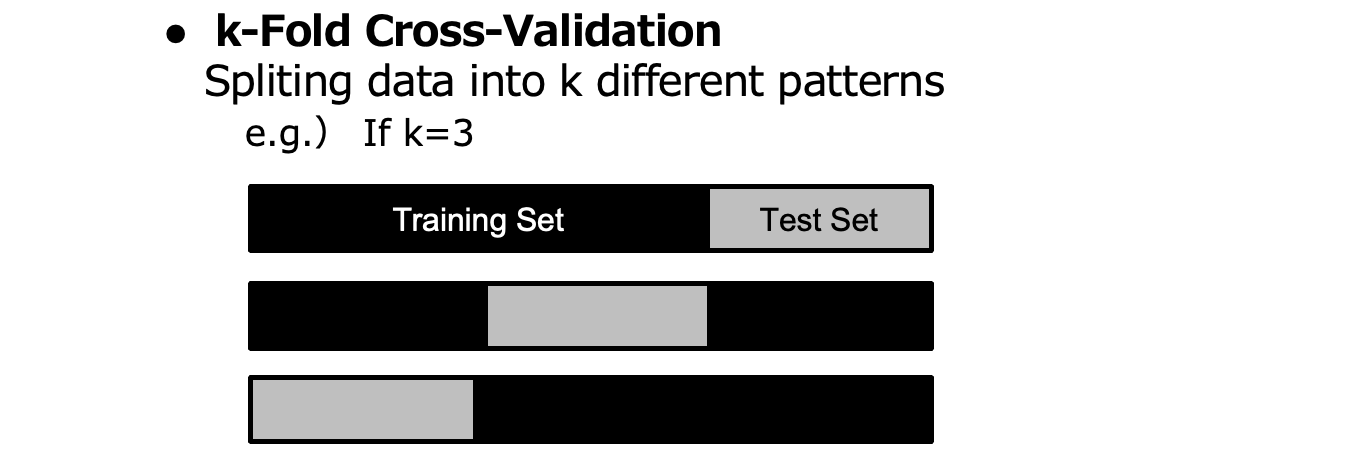

To perform cross-validation,  we will import the `KFold` class and the `cross_val_score()` function from the `sklearn.model_selection` module. We will set the `n_splits` parameter of `KFold` to 5, meaning the data will be divided into five parts. One of the five parts will be used as test data, while the other four will be used for training. In other words, during cross-validation, each split is used once as test data, and the others are used for training. By setting `shuffle=True`, the data is randomly shuffled before splitting. Additionally, setting `random_state` ensures reproducibility of the shuffling process. For example, setting `random_state=0` ensures the same shuffle each time, providing consistency in experimental results.

The `cross_val_score()` function performs cross-validation on the given model and data, returning a score for each split.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score

model = LinearRegression()

kf = KFold(n_splits=5, shuffle=True, random_state=0)

scores = cross_val_score(model, X, y, cv=kf, scoring='r2')

With this, model training and evaluation are complete.

Accuracy is measured using the **coefficient of determination**,
$𝑅^2$, which indicates how well the model fits the data. The value ranges from 0 to 1 and is calculated using the following formula:

\begin{eqnarray}
R^2 = 1 - \frac{\sum_{i=1}^n (y_i - f(x_i))^2}{\sum_{i=1}^n (y_i - \bar{y})^2}
\end{eqnarray}

Where:
- $n$ is the total number of data points (rows in the dataframe),
- $y_i$ is the actual value of the i-th point,
- $f(x_i)$ is the predicted value for the i-th data point,
- $\bar{y}$ is the mean of the actual values $y$.


The numerator,  $\sum_{i=1}^n (y_i - f(x_i))^2$, is the sum of squared errors, which measures the discrepancy between actual and predicted values. The smaller this value is, the more accurate the predictions are, and consequently, the closer $R^2$ will be to 1.

Since the data was split into 5 parts, we obtain 5 different coefficients of determination.

Here's the output:

In [ ]:
print('R² score for each split:', scores)
print('Mean R² score from cross-validation:', scores.mean())

Coefficient of determination for each split: [0.74570389 0.8328456  0.83827622 0.6746478  0.71840916]
Mean coefficient of determination in cross-validation: 0.7619765325212035


The mean $𝑅^2$ from cross-validation is approximately 0.762.

Generally, there are no absolute standards for $𝑅^2$, and acceptable values vary by field. Therefore, it's important to compare $𝑅^2$ to assess model accuracy. While 0.762 is a relatively high value, since
$𝑅^2$ approaches 1 as the model's predictive accuracy improves, there is still room for further improvement.

##1.4.Practice Problems

**Q1-1.** Download the `Regression_Lv1_Practice.csv` from the link below, upload the file, and read it as a pandas DataFrame. Then, display the first 5 rows to check the data.

[Regression_Lv1_Practice.csv](https://drive.google.com/file/d/1a21m4u-TWga-kUj6jy4Gbz6kvS6VlyZy/view?usp=drive_link)



**Q1-2.**  Using the DataFrame from Q1-1, check the number of missing values in each column.

**Q1-3.**  Create a new DataFrame by removing the rows with missing values from the DataFrame in Q1-2.

**Q1-4.** Using the DataFrame created from Q1-3, create a scatter plot with **`engine-size`** on the x-axis and **`price`** on the y-axis.